In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("./train.csv", usecols=["Age","Fare","Survived"])
df.head(3)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250


In [3]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [26]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())

In [6]:
df["Age"].isnull().sum()

np.int64(177)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [28]:
X = df.iloc[:,1:3]
y= df.iloc[:,0]

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
import matplotlib.pyplot as plt

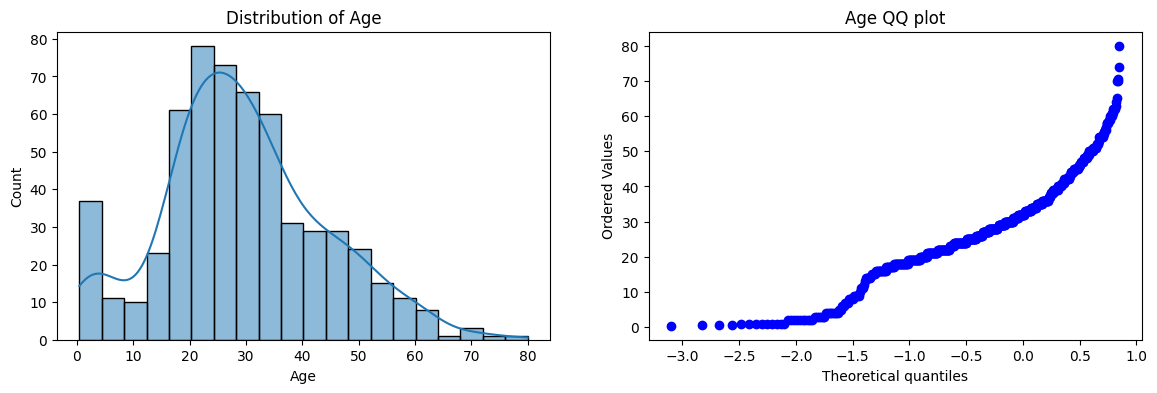

In [20]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(X_train["Age"], kde=True)
plt.title("Distribution of Age")
plt.subplot(1,2,2)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ plot")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_21996\3638316134.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Fare"])


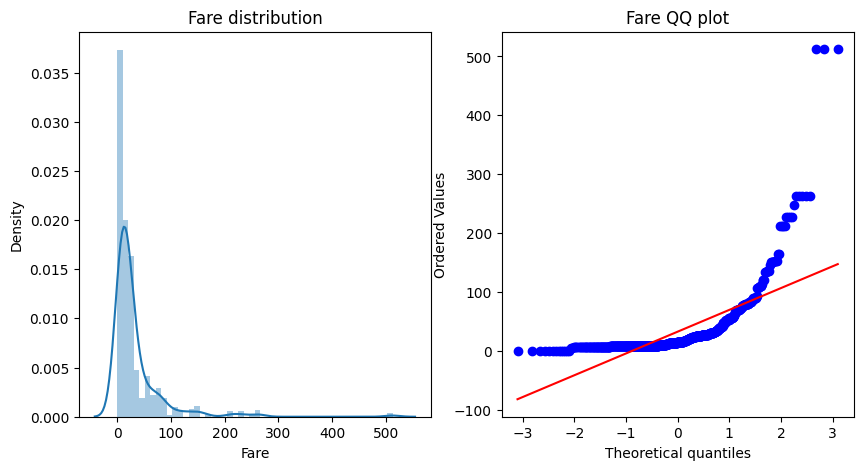

In [21]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(X_train["Fare"])
plt.title("Fare distribution")
plt.subplot(1,2,2)
stats.probplot(X_train["Fare"], dist="norm", plot=plt)
plt.title("Fare QQ plot")
plt.show()

In [22]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

In [30]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred1=clf1.predict(X_test)
y_pred2=clf2.predict(X_test)

print("Logistic Regression Accuracy: ",accuracy_score(y_test,y_pred1))
print("Decision Tree Accuracy: ",accuracy_score(y_test,y_pred2)) 

Logistic Regression Accuracy:  0.6480446927374302
Decision Tree Accuracy:  0.6983240223463687


In [31]:
trf = FunctionTransformer(func=np.log1p)

In [32]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [33]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

clf1.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred1=clf1.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)

print("Logistic Regression Accuracy: ",accuracy_score(y_test,y_pred1))
print("Decision Tree Accuracy: ",accuracy_score(y_test,y_pred2))

Logistic Regression Accuracy:  0.6815642458100558
Decision Tree Accuracy:  0.6703910614525139


In [34]:
X_transformed = trf.fit_transform(X)

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf1,X_transformed,y,scoring='accuracy',cv=10)))
print("DT", np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6611111111111111


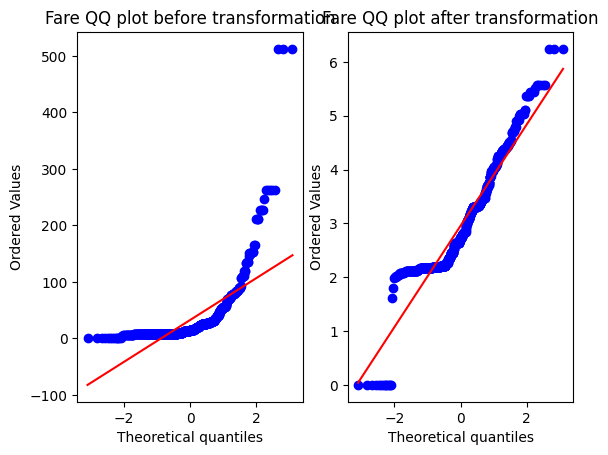

In [38]:
plt.Figure(figsize=(14,5))
plt.subplot(1,2,1)
stats.probplot(X_train["Fare"],dist="norm",plot=plt)
plt.title("Fare QQ plot before transformation")

plt.subplot(1,2,2)
stats.probplot(X_train_transformed["Fare"],dist="norm",plot=plt)
plt.title("Fare QQ plot after transformation")
plt.show()

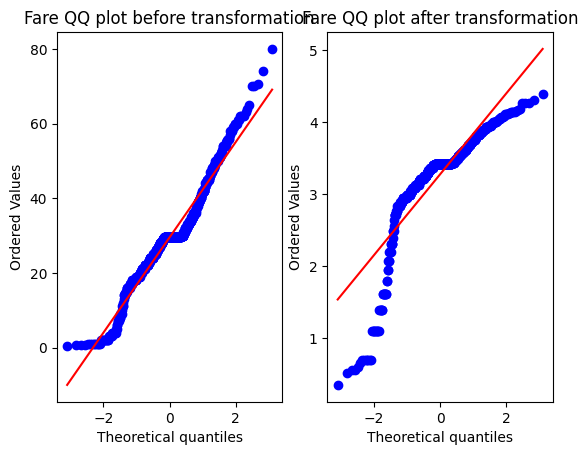

In [39]:
plt.Figure(figsize=(14,5))
plt.subplot(1,2,1)
stats.probplot(X_train["Age"],dist="norm",plot=plt)
plt.title("Fare QQ plot before transformation")

plt.subplot(1,2,2)
stats.probplot(X_train_transformed["Age"],dist="norm",plot=plt)
plt.title("Fare QQ plot after transformation")
plt.show()

In [40]:
trf2 = ColumnTransformer([("log",FunctionTransformer(np.log1p),["Fare"])],remainder="passthrough")
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [41]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

clf1.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred1=clf1.predict(X_test_transformed2)
y_pred2=clf2.predict(X_test_transformed2)

print("Logistic Regression Accuracy: ",accuracy_score(y_test,y_pred1))
print("Decision Tree Accuracy: ",accuracy_score(y_test,y_pred2))

Logistic Regression Accuracy:  0.6703910614525139
Decision Tree Accuracy:  0.6815642458100558


In [42]:
# cross validation
X_transformed2 = trf2.fit_transform(X)
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf1,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT", np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6599625468164793


In [44]:
def apply_transfrom(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([("log",FunctionTransformer(transform),["Fare"])],remainder="passthrough")
    X_trans = trf.fit_transform(X)
    clf1 = LogisticRegression()

    print("LR", np.mean(cross_val_score(clf1,X_trans,y,scoring='accuracy',cv=10)))

    plt.Figure(figsize=(14,5))
    plt.subplot(1,2,1)
    stats.probplot(X["Fare"],dist="norm",plot=plt)
    plt.title("Fare QQ plot before transformation")

    plt.subplot(1,2,2)
    stats.probplot(X_trans[:,0],dist="norm",plot=plt)
    plt.title("Fare QQ plot after transformation")
    plt.show()


LR 0.6195131086142323


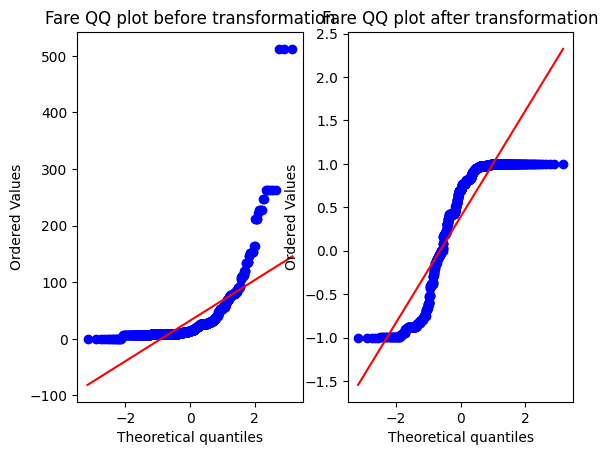

In [45]:
apply_transfrom(np.sin)

LR 0.61729088639201


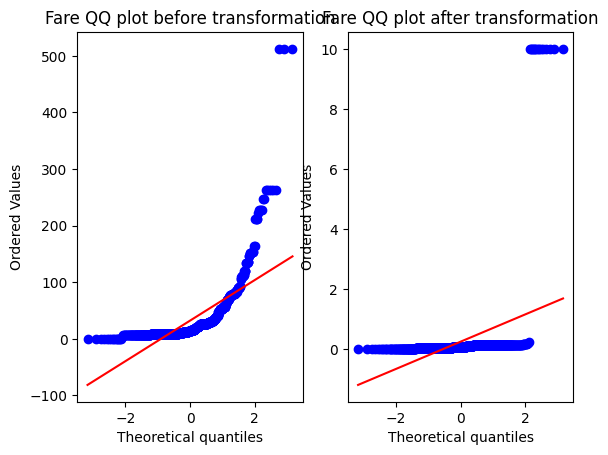

In [46]:
apply_transfrom(lambda x: 1/(x+0.1))

LR 0.6589013732833957


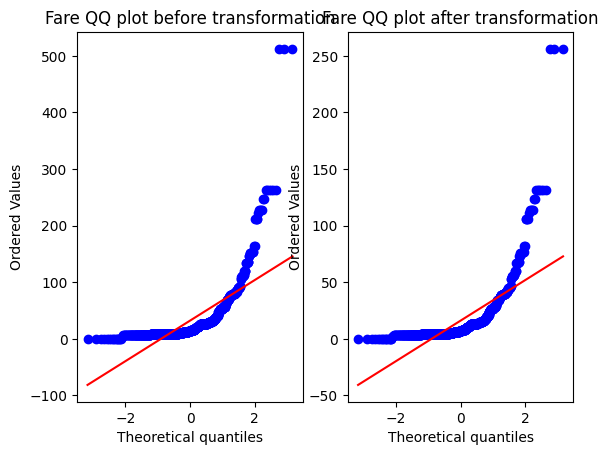

In [47]:
apply_transfrom(lambda x: x**1/2)